# Chest X-ray anatomy segmentation on Kaggle

Notebook ngắn để chạy `ianpan/chest-x-ray-basic` trên dataset pneumonia ở Kaggle, sinh mask giải phẫu và trực quan overlay lên ảnh X-quang.

Lưu ý: model này dùng `trust_remote_code=True`, nên Kaggle notebook cần bật Internet để tải model từ Hugging Face lần đầu.

In [10]:
import os
import re
import subprocess
import sys
from pathlib import Path
import random

# Bootstrap nhẹ để anatomy + ROSALIA cùng chạy trong một Kaggle session.
# Không upgrade/downgrade Pillow, NumPy, Torch, OpenCV, Matplotlib: đây là các binary package
# Kaggle đã chuẩn bị sẵn; đụng vào dễ gây lỗi PIL _imaging/Core version mismatch.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

def ensure_packages(import_to_package):
    missing_packages = []
    for import_name, package_spec in import_to_package.items():
        try:
            __import__(import_name)
        except ImportError:
            missing_packages.append(package_spec)

    if missing_packages:
        print("Installing missing lightweight packages:", missing_packages)
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "--no-cache-dir",
            "-q",
            *missing_packages,
        ])

ensure_packages({
    "timm": "timm>=0.9.12",
    "sentencepiece": "sentencepiece",
    "peft": "peft==0.8.2",
    "einops": "einops==0.4.1",
    "accelerate": "accelerate>=0.27.0",
    "bitsandbytes": "bitsandbytes>=0.43.1",
    "pycocotools": "pycocotools>=2.0.7",
})

def clear_pil_modules():
    for module_name in list(sys.modules):
        if module_name == "PIL" or module_name.startswith("PIL."):
            del sys.modules[module_name]

def import_pillow_safely():
    """Import Pillow; repair only if the current Kaggle session has a PIL binary mismatch."""
    try:
        from PIL import Image
        return Image
    except ImportError as exc:
        msg = str(exc)
        match = re.search(r"Core version:\s*([0-9.]+)\s+Pillow version:\s*([0-9.]+)", msg)
        if not match:
            raise

        core_version, pillow_version = match.groups()
        print(f"Detected broken Pillow session: core={core_version}, pillow={pillow_version}")
        print(f"Repairing Pillow to match loaded core version: pillow=={core_version}")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "--force-reinstall",
            "--no-cache-dir",
            "--no-deps",
            "-q",
            f"pillow=={core_version}",
        ])
        clear_pil_modules()
        from PIL import Image
        return Image

import cv2
import matplotlib.pyplot as plt
import numpy as np
Image = import_pillow_safely()
import timm
import torch
import torch.nn.functional as F
import accelerate
import bitsandbytes as bnb
import peft
from transformers import AutoModel

print("python:", sys.executable)
print("pillow:", Image.__version__)
print("timm:", timm.__version__)
print("torch:", torch.__version__)
print("transformers:", __import__("transformers").__version__)
print("accelerate:", accelerate.__version__, "bitsandbytes:", bnb.__version__, "peft:", peft.__version__)

def patch_missing_tied_weight_keys():
    """Fallback cho runtime transformers mới khi remote custom model thiếu attr này."""
    original_getattr = torch.nn.Module.__getattr__
    if getattr(torch.nn.Module, "_cxr_all_tied_patch", False):
        return

    def safe_getattr(self, name):
        if name == "all_tied_weights_keys":
            return {}
        return original_getattr(self, name)

    torch.nn.Module.__getattr__ = safe_getattr
    torch.nn.Module._cxr_all_tied_patch = True

plt.rcParams["figure.dpi"] = 130
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "ianpan/chest-x-ray-basic"

DATA_ROOT = Path("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/")
OUT_DIR = Path("/kaggle/working/anatomy_masks")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"device: {DEVICE}")
print(f"data root exists: {DATA_ROOT.exists()} -> {DATA_ROOT}")

python: /usr/bin/python3
pillow: 11.3.0
timm: 1.0.26
torch: 2.10.0+cu128
transformers: 5.0.0
accelerate: 1.13.0 bitsandbytes: 0.50.2 peft: 0.19.1
device: cuda
data root exists: True -> /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia


## Chọn một vài ảnh mẫu

Cell này dò toàn bộ ảnh `.jpeg/.jpg/.png` dưới thư mục bạn đưa vào. Nếu Kaggle mount dataset ở một path hơi khác, chỉ cần sửa `DATA_ROOT` ở cell trên.

In [11]:
def is_real_xray_file(path: Path):
    # Kaggle bản chest-xray-pneumonia có thể lẫn metadata từ macOS:
    # `__MACOSX/.../._file.jpeg`. Đây không phải ảnh hợp lệ nên cv2.imread sẽ trả None.
    parts = set(path.parts)
    if "__MACOSX" in parts:
        return False
    if path.name.startswith("._"):
        return False
    return path.suffix.lower() in {".jpeg", ".jpg", ".png"}

def find_images(root: Path):
    return sorted(p for p in root.rglob("*") if p.is_file() and is_real_xray_file(p))

image_paths = find_images(DATA_ROOT)
if not image_paths:
    raise FileNotFoundError(
        f"Không tìm thấy ảnh dưới {DATA_ROOT}. Hãy kiểm tra lại Kaggle input path."
    )

valid_paths = []
for p in image_paths:
    if cv2.imread(str(p), cv2.IMREAD_GRAYSCALE) is not None:
        valid_paths.append(p)

if not valid_paths:
    raise FileNotFoundError("Tìm thấy file ảnh theo đuôi nhưng OpenCV không đọc được file nào.")

random.seed(42)
sample_paths = random.sample(valid_paths, k=min(6, len(valid_paths)))

print(f"found image files: {len(image_paths)}")
print(f"opencv-readable images: {len(valid_paths)}")
for p in sample_paths:
    print(p)

found image files: 11712
opencv-readable images: 11712
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person487_bacteria_2060.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL/NORMAL2-IM-1203-0001.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA/person1613_virus_2799.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA/person459_bacteria_1956.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA/person332_bacteria_1531.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA/person257_bacteria_1195.jpeg


## Load model và chạy anatomy segmentation

In [12]:
patch_missing_tied_weight_keys()
model = AutoModel.from_pretrained(MODEL_ID, trust_remote_code=True)
model = model.eval().to(DEVICE)

LABELS = {
    1: "right_lung",
    2: "left_lung",
    3: "heart",
}

COLORS = {
    1: np.array([0, 180, 255], dtype=np.uint8),
    2: np.array([0, 220, 120], dtype=np.uint8),
    3: np.array([255, 80, 120], dtype=np.uint8),
}

VIEW_NAMES = ["AP", "PA", "lateral"]

def read_gray(path: Path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Không đọc được ảnh: {path}")
    return img

def logits_to_label_mask(mask_logits: torch.Tensor):
    """Return label mask with 0=background, 1=right lung, 2=left lung, 3=heart."""
    labels = mask_logits.argmax(1).squeeze(0).detach().cpu().numpy().astype(np.uint8)

    # Model card hiện mô tả labels 1..3 sau argmax. Nếu một bản model trả đúng 3 kênh
    # không background, dịch nhãn lên 1 để giữ mapping anatomy ổn định.
    if mask_logits.shape[1] == 3 and labels.max() <= 2:
        labels = labels + 1
    return labels

def segment_one(path: Path):
    img = read_gray(path)
    x = model.preprocess(img)
    x = torch.from_numpy(x).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

    with torch.inference_mode():
        out = model(x)

    mask_logits = out["mask"]
    mask = logits_to_label_mask(mask_logits)
    mask_prob = torch.softmax(mask_logits, dim=1)
    mask_prob = F.interpolate(mask_prob, size=img.shape, mode="bilinear", align_corners=False)
    mask_prob = mask_prob.squeeze(0).detach().cpu().numpy()
    if mask.shape != img.shape:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

    view_id = int(out["view"].argmax(1).item()) if "view" in out else None
    age = float(out["age"].squeeze().item()) if "age" in out else None
    female = bool((out["female"].squeeze() >= 0.5).item()) if "female" in out else None

    return {
        "path": path,
        "image": img,
        "mask": mask,
        "mask_prob": mask_prob,
        "view": VIEW_NAMES[view_id] if view_id is not None and view_id < len(VIEW_NAMES) else None,
        "age": age,
        "female": female,
    }

results = [segment_one(p) for p in sample_paths]
print(f"segmented: {len(results)} images")

Loading weights:   0%|          | 0/838 [00:00<?, ?it/s]

segmented: 6 images


## Trực quan overlay mask trên ảnh

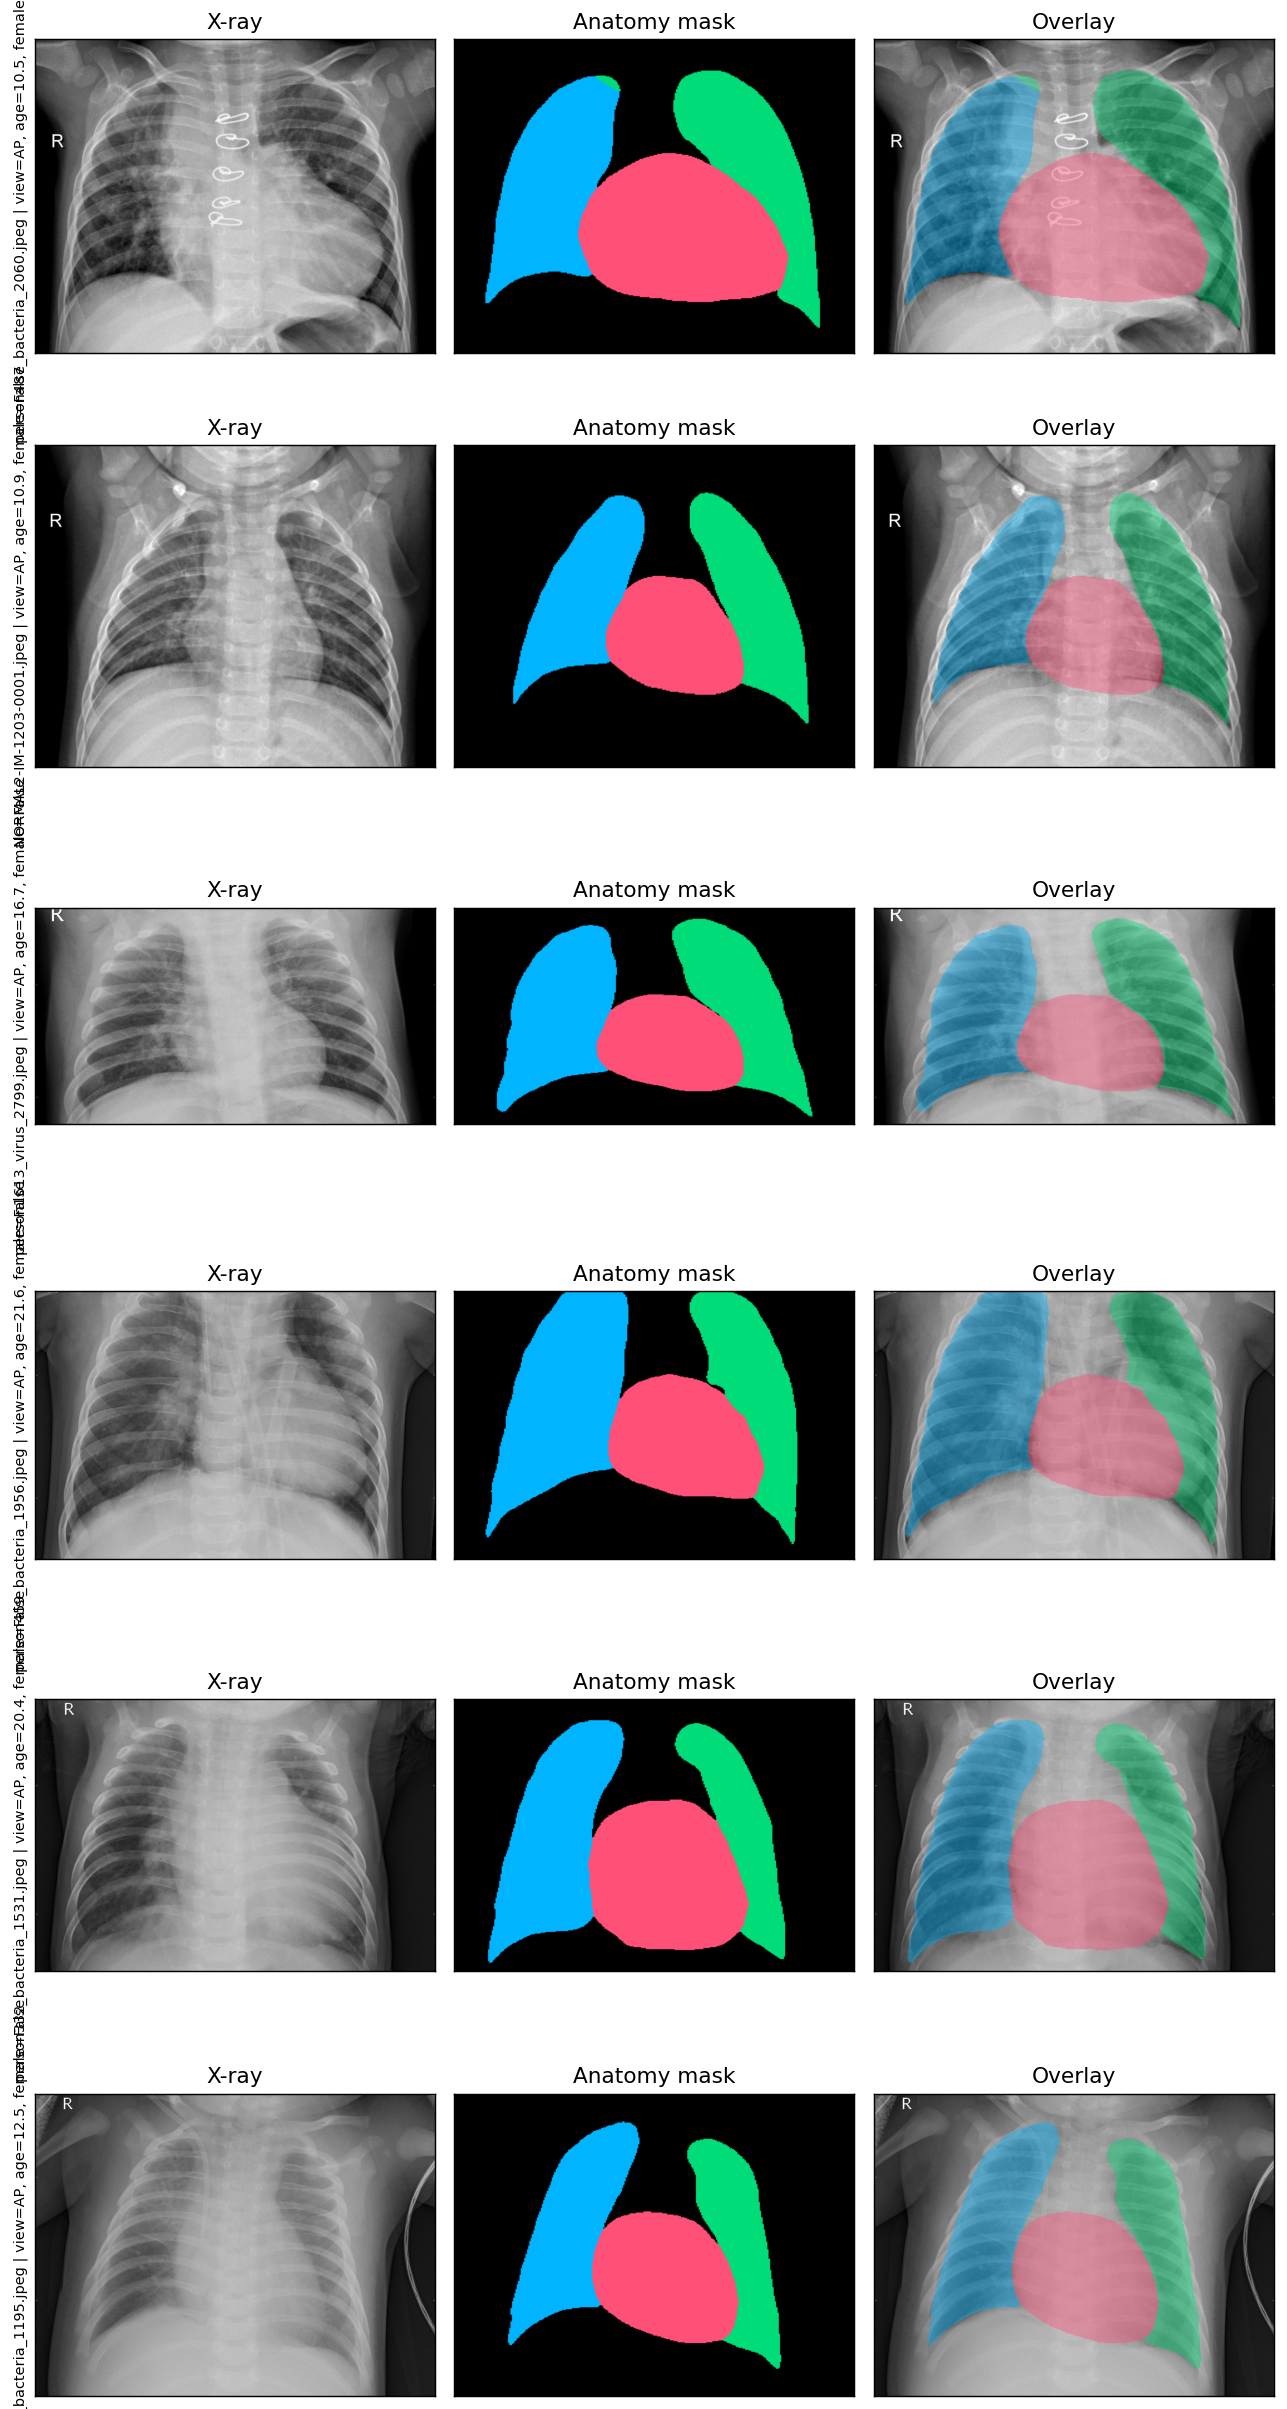

Legend:
  1: right_lung
  2: left_lung
  3: heart


In [13]:
def make_overlay(gray: np.ndarray, mask: np.ndarray, alpha: float = 0.42):
    base = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    color_mask = np.zeros_like(base)
    anatomy_pixels = np.zeros(mask.shape, dtype=bool)

    for label, color in COLORS.items():
        pixels = mask == label
        color_mask[pixels] = color
        anatomy_pixels |= pixels

    overlay = base.copy()
    overlay[anatomy_pixels] = (
        (1 - alpha) * base[anatomy_pixels] + alpha * color_mask[anatomy_pixels]
    ).astype(np.uint8)
    return overlay

def summarize_mask(mask: np.ndarray):
    total = mask.size
    return {name: float((mask == label).sum() / total) for label, name in LABELS.items()}

fig, axes = plt.subplots(len(results), 3, figsize=(10, 3.2 * len(results)))
if len(results) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, item in enumerate(results):
    img = item["image"]
    mask = item["mask"]
    overlay = make_overlay(img, mask)

    mask_vis = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for label, color in COLORS.items():
        mask_vis[mask == label] = color

    meta = []
    if item["view"] is not None:
        meta.append(f"view={item['view']}")
    if item["age"] is not None:
        meta.append(f"age={item['age']:.1f}")
    if item["female"] is not None:
        meta.append(f"female={item['female']}")
    title = item["path"].name + (" | " + ", ".join(meta) if meta else "")

    axes[row, 0].imshow(img, cmap="gray")
    axes[row, 0].set_title("X-ray")
    axes[row, 1].imshow(mask_vis)
    axes[row, 1].set_title("Anatomy mask")
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title("Overlay")
    axes[row, 0].set_ylabel(title, fontsize=8)

    for col in range(3):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

plt.tight_layout()
plt.show()

print("Legend:")
for label, name in LABELS.items():
    print(f"  {label}: {name}")

## Sinh JSON anatomy + CTR

In [14]:
import json

def anatomy_confidence(mask: np.ndarray, prob, label: int):
    pixels = mask == label
    if prob is None:
        return None
    if not pixels.any():
        return 0.0

    # Nếu model trả 4 kênh: 0=background, 1=right lung, 2=left lung, 3=heart.
    # Nếu model trả 3 kênh: 0=right lung, 1=left lung, 2=heart.
    channel = label if prob.shape[0] >= 4 else label - 1
    return round(float(prob[channel][pixels].mean()), 3)

def mask_width(mask: np.ndarray, labels):
    pixels = np.isin(mask, labels)
    if not pixels.any():
        return 0
    xs = np.where(pixels)[1]
    return int(xs.max() - xs.min())

def build_anatomy_json(item):
    mask = item["mask"]
    prob = item.get("mask_prob")
    left_lung_area = int((mask == 2).sum())
    right_lung_area = int((mask == 1).sum())
    heart_area = int((mask == 3).sum())
    heart_width = mask_width(mask, [3])
    thoracic_width = mask_width(mask, [1, 2])
    ctr = round(float(heart_width / thoracic_width), 3) if thoracic_width else None

    return {
        "image": str(item["path"]),
        "anatomy": {
            "left_lung": {"confidence": anatomy_confidence(mask, prob, 2)},
            "right_lung": {"confidence": anatomy_confidence(mask, prob, 1)},
            "heart": {"confidence": anatomy_confidence(mask, prob, 3)},
        },
        "measurements": {
            "left_lung_area": left_lung_area,
            "right_lung_area": right_lung_area,
            "heart_area": heart_area,
            "heart_width": heart_width,
            "thoracic_width": thoracic_width,
            "ctr": ctr,
        },
    }

if any("mask_prob" not in item for item in results):
    print("Cảnh báo: results hiện chưa có mask_prob. Hãy chạy lại cell 'Load model và chạy anatomy segmentation' để có confidence thật từ model.")

anatomy_outputs = [build_anatomy_json(item) for item in results]

# Nếu chỉ muốn format đúng như ví dụ cho 1 ảnh, xem anatomy_outputs[0].
print(json.dumps(anatomy_outputs[0], indent=4, ensure_ascii=False))

# Nếu muốn toàn bộ ảnh sample:
# print(json.dumps(anatomy_outputs, indent=4, ensure_ascii=False))

{
    "image": "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person487_bacteria_2060.jpeg",
    "anatomy": {
        "left_lung": {
            "confidence": 0.472
        },
        "right_lung": {
            "confidence": 0.473
        },
        "heart": {
            "confidence": 0.474
        }
    },
    "measurements": {
        "left_lung_area": 219747,
        "right_lung_area": 254431,
        "heart_area": 350638,
        "heart_width": 804,
        "thoracic_width": 1279,
        "ctr": 0.629
    }
}
